In [ ]:
# Example to run the parachor.py module and running together with thermoift

import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/parachorpy

from Interfacethermopy import parachor as IFT
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker

In [2]:
if __name__ == '__main__':
    
    json_files = ["Mulero_2012.json"]
    model = IFT.InterfacialTension(json_files)
    
    model.ctREFPROP_init('~/Software/REFPROP/REFPROP-cmake/build', gerg_enable=1)
    
    MIXTURE  = "CO2;Methane"
    z        = [0.95, 0.05]
    kij      = 0.0
    phi_ij   = 1.0
    
    #### Option 1: only at saturation boundaries (bubble + dew per temperature) #####
    # df, df_bub, df_dew = model.compute_IFT_envelope(
    #     mixture  = MIXTURE,
    #     z        = z,
    #     T_start  = 200,
    #     kij      = kij,
    #     phi_ij   = phi_ij,
    #     tol_frac = 5e-6,
    #     mode     = "saturation")
    
    #### Option 2: full sweep across the two-phase interior ######
    df, df_bub, df_dew = model.compute_IFT_envelope(
        mixture  = MIXTURE,
        z        = z,
        T_start  = 200,
        N_points = 20,
        kij      = kij,
        phi_ij   = phi_ij,
        tol_frac = 5e-6,
        mode     = "envelope")
    
    csv_path = "IFT_results.csv"
    df.to_csv(csv_path, index=False)

REFPROP version = 10.0
GERG-2008 model = Enabled
Mixture critical point:  Tc = 300.7060 K  |  Pc = 77.9096 bar
Mode: 'envelope' | N_points = 20
Given temperature is less than or equal to max(TMIN, TTRP) for CO2
Computing interfacial tension at T = 1.1*max(TMIN, TTRP) for Parachor method for mixtures
Parachor number calculated: 77.784598 [kg/m3]n ·mN/m
Given temperature is greater than Tc (190.564) for Methane
Computing interfacial tension at T = 0.9*190.564 for Parachor method
Parachor number calculated: 75.160375 [kg/m3]n ·mN/m
Given temperature is less than or equal to max(TMIN, TTRP) for CO2
Computing interfacial tension at T = 1.1*max(TMIN, TTRP) for Parachor method for mixtures
Parachor number calculated: 77.784598 [kg/m3]n ·mN/m
Given temperature is greater than Tc (190.564) for Methane
Computing interfacial tension at T = 0.9*190.564 for Parachor method
Parachor number calculated: 75.160375 [kg/m3]n ·mN/m
Given temperature is less than or equal to max(TMIN, TTRP) for CO2
Computi

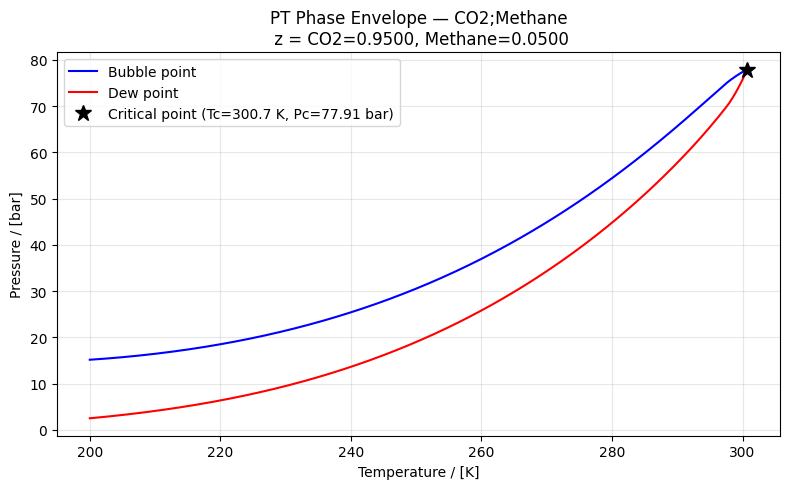

In [3]:
env = model.PT_envelope_curves("IFT_results.csv", n_smooth=400)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(env["T_bub_smooth"], env["P_bub_smooth"], color="b", label="Bubble point")
ax.plot(env["T_dew_smooth"], env["P_dew_smooth"], color="r", label="Dew point")
ax.plot(env["Tc"], env["Pc"], "k*", ms=12,
        label=f"Critical point (Tc={env['Tc']:.1f} K, Pc={env['Pc']:.2f} bar)")

# Optional raw points
# ax.plot(env["T_bub_raw"], env["P_bub_raw"], "bo", ms=3, alpha=0.4)
# ax.plot(env["T_dew_raw"], env["P_dew_raw"], "ro", ms=3, alpha=0.4)

ax.set_xlabel("Temperature / [K]")
ax.set_ylabel("Pressure / [bar]")
ax.set_title(f"PT Phase Envelope — {env['mixture']}\n z = {env['z_label']}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

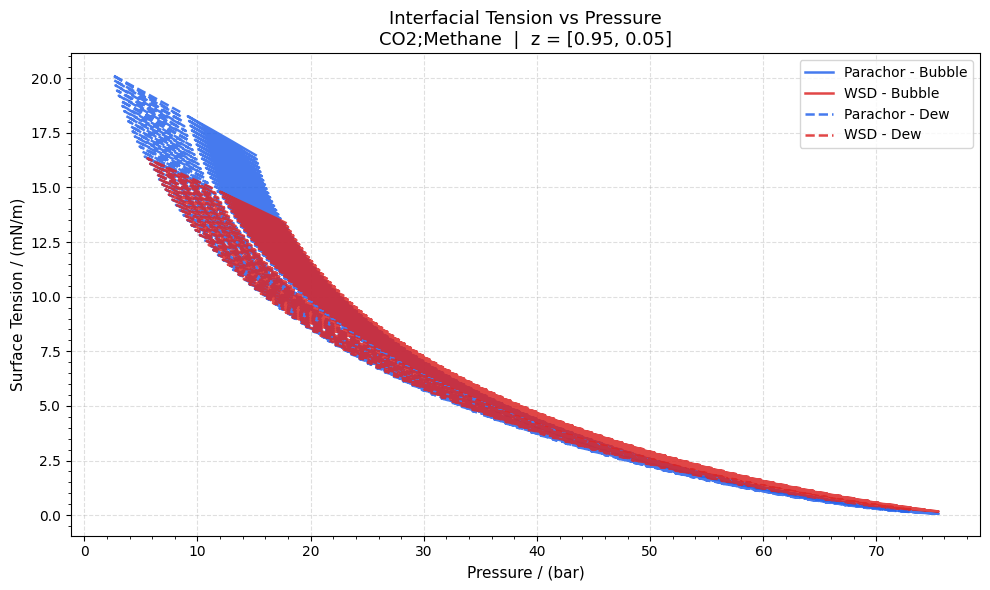

In [4]:

df = pd.read_csv("IFT_results.csv")

# Filter each model independently — keeps rows where that model has a valid value
df_bub_parachor = df_bub[df_bub["gamma_Parachor_mN_m"] >= 1e-4].reset_index(drop=True)
df_bub_wsd      = df_bub[df_bub["gamma_WSD_mN_m"]      >= 1e-4].reset_index(drop=True)
df_dew_parachor = df_dew[df_dew["gamma_Parachor_mN_m"] >= 1e-4].reset_index(drop=True)
df_dew_wsd      = df_dew[df_dew["gamma_WSD_mN_m"]      >= 1e-4].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

plot_config = [
    (df_bub_parachor, "gamma_Parachor_mN_m", "Parachor - Bubble", "#2563EB", "-",  "None"),
    (df_bub_wsd,      "gamma_WSD_mN_m",      "WSD - Bubble",      "#DC2626", "-",  "None"),
    (df_dew_parachor, "gamma_Parachor_mN_m", "Parachor - Dew",    "#2563EB", "--", "None"),
    (df_dew_wsd,      "gamma_WSD_mN_m",      "WSD - Dew",         "#DC2626", "--", "None"),
]

for df_plot, col, label, color, ls, marker in plot_config:
    ax.plot(df_plot["P_bar"], df_plot[col],
            linestyle=ls, marker=marker, markersize=3,
            linewidth=1.8, color=color, label=label, alpha=0.85)

ax.set_title(f"Interfacial Tension vs Pressure\n{MIXTURE}  |  z = {z}",
             fontsize=13)
ax.set_xlabel("Pressure / (bar)", fontsize=11)
ax.set_ylabel("Surface Tension / (mN/m)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("IFT_vs_Pressure.png", dpi=150, bbox_inches='tight')
plt.show()